In [24]:
# ============================================
# SECTION 04 - EXPLORATORY DATA ANALYSIS
# Expernetic Data Engineering Assignment
# Candidate: Ishini Ellewela
# Dataset: Inside Airbnb - Bangkok, Thailand
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Paths
data_path = r"C:\Users\Ishini\Desktop\Expernetic_Assignment\data"
charts_path = r"C:\Users\Ishini\Desktop\Expernetic_Assignment\charts"

print("Libraries imported successfully!")

Libraries imported successfully!


In [25]:
# Load all datasets
listings = pd.read_csv(os.path.join(data_path, "listings.csv.gz"), compression='gzip')
reviews = pd.read_csv(os.path.join(data_path, "reviews.csv.gz"), compression='gzip')
calendar = pd.read_csv(os.path.join(data_path, "calendar.csv.gz"), compression='gzip')
neighbourhoods = pd.read_csv(os.path.join(data_path, "neighbourhoods.csv"))

print(f"Listings loaded: {listings.shape[0]:,} rows")
print(f"Reviews loaded: {reviews.shape[0]:,} rows")
print(f"Calendar loaded: {calendar.shape[0]:,} rows")
print(f"Neighbourhoods loaded: {neighbourhoods.shape[0]:,} rows")

Listings loaded: 31,069 rows
Reviews loaded: 693,647 rows
Calendar loaded: 11,340,155 rows
Neighbourhoods loaded: 50 rows


In [26]:
# Clean price column
listings['price_clean'] = (
    listings['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Remove outliers
listings_clean = listings[
    (listings['price_clean'] > 0) &
    (listings['price_clean'] < 10000)
].copy()

print("=== PRICE CLEANING RESULTS ===")
print(f"Original listings: {len(listings):,}")
print(f"After cleaning: {len(listings_clean):,}")
print(f"Removed: {len(listings) - len(listings_clean):,} listings")
print(f"\nPrice Statistics (THB):")
print(f"  Minimum:  ฿{listings_clean['price_clean'].min():,.0f}")
print(f"  Maximum:  ฿{listings_clean['price_clean'].max():,.0f}")
print(f"  Mean:     ฿{listings_clean['price_clean'].mean():,.0f}")
print(f"  Median:   ฿{listings_clean['price_clean'].median():,.0f}")
print(f"  Std Dev:  ฿{listings_clean['price_clean'].std():,.0f}")

=== PRICE CLEANING RESULTS ===
Original listings: 31,069
After cleaning: 28,204
Removed: 2,865 listings

Price Statistics (THB):
  Minimum:  ฿1
  Maximum:  ฿9,999
  Mean:     ฿2,031
  Median:   ฿1,549
  Std Dev:  ฿1,585


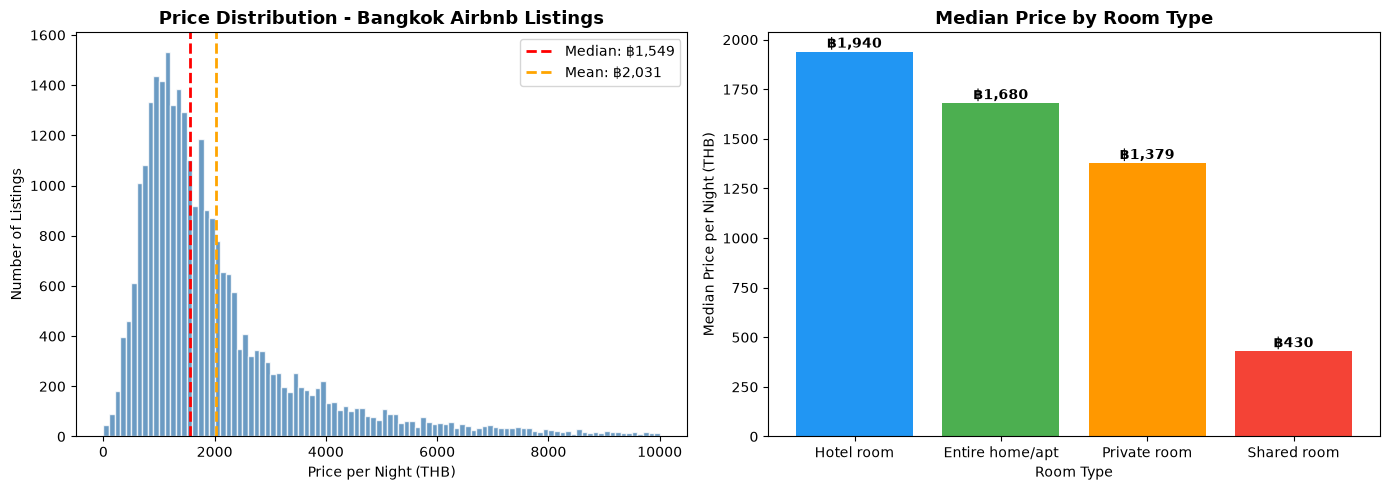

=== BUSINESS INTERPRETATION ===
Price distribution is right-skewed. Most listings are affordable
(median ฿1,549/night) but luxury properties
pull the mean up to ฿2,031/night.

Room type breakdown:
  Hotel room: ฿1,940 median/night
  Entire home/apt: ฿1,680 median/night
  Private room: ฿1,379 median/night
  Shared room: ฿430 median/night


In [27]:
# VISUALISATION 1: Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(listings_clean['price_clean'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Price Distribution - Bangkok Airbnb Listings', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price per Night (THB)')
axes[0].set_ylabel('Number of Listings')
axes[0].axvline(listings_clean['price_clean'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: ฿{listings_clean['price_clean'].median():,.0f}")
axes[0].axvline(listings_clean['price_clean'].mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean: ฿{listings_clean['price_clean'].mean():,.0f}")
axes[0].legend()

room_prices = listings_clean.groupby('room_type')['price_clean'].median().sort_values(ascending=False)
axes[1].bar(room_prices.index, room_prices.values, color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
axes[1].set_title('Median Price by Room Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Median Price per Night (THB)')
for i, (idx, val) in enumerate(room_prices.items()):
    axes[1].text(i, val + 20, f'฿{val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'price_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("=== BUSINESS INTERPRETATION ===")
print(f"Price distribution is right-skewed. Most listings are affordable")
print(f"(median ฿{listings_clean['price_clean'].median():,.0f}/night) but luxury properties")
print(f"pull the mean up to ฿{listings_clean['price_clean'].mean():,.0f}/night.")
print(f"\nRoom type breakdown:")
for room, price in room_prices.items():
    print(f"  {room}: ฿{price:,.0f} median/night")

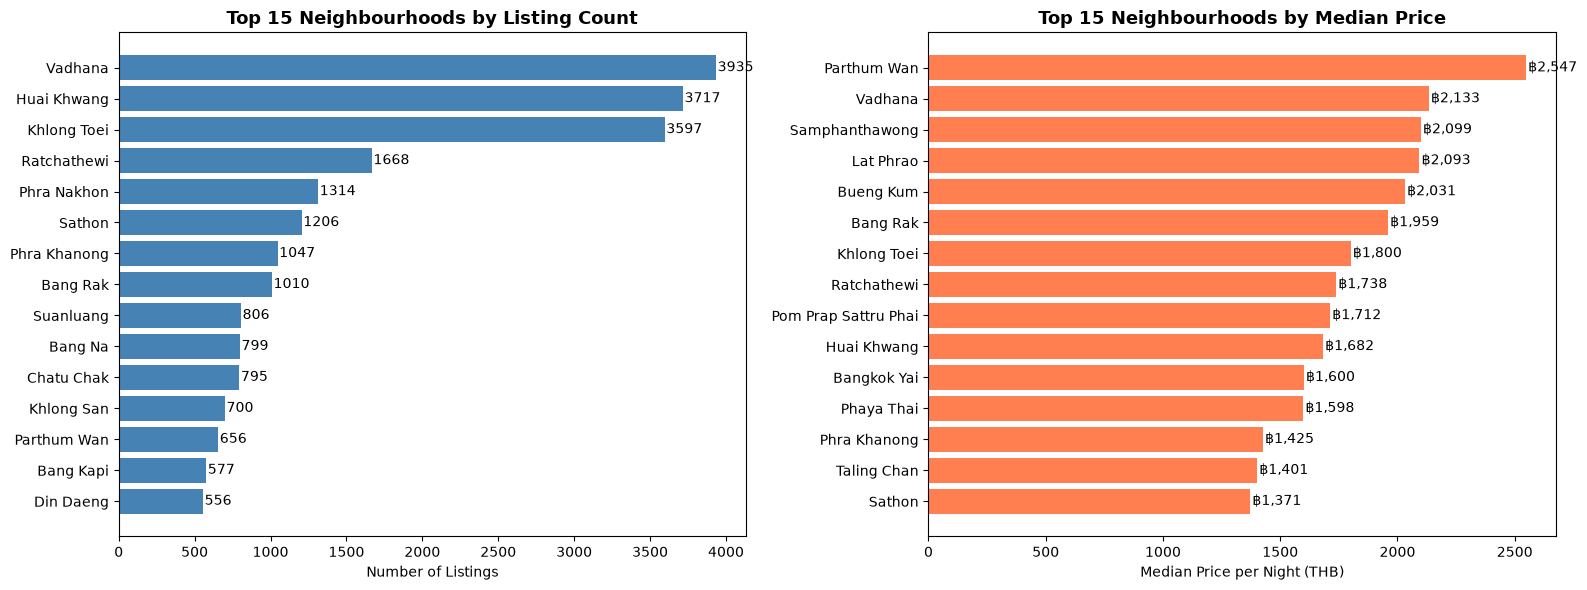

=== BUSINESS INTERPRETATION ===
Most listed neighbourhood: Vadhana (3,935 listings)
Most expensive neighbourhood: Parthum Wan (฿2,547 median/night)
Least expensive in top 15: Sathon (฿1,371 median/night)
Vadhana dominates in volume but Parthum Wan commands premium prices —
suggesting Parthum Wan is Bangkok's luxury short-term rental hub.


In [28]:
# VISUALISATION 2: Neighbourhood Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

neighbourhood_counts = listings_clean['neighbourhood_cleansed'].value_counts().head(15)
axes[0].barh(neighbourhood_counts.index[::-1], neighbourhood_counts.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Neighbourhoods by Listing Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Listings')
for i, v in enumerate(neighbourhood_counts.values[::-1]):
    axes[0].text(v + 10, i, str(v), va='center')

neighbourhood_prices = listings_clean.groupby('neighbourhood_cleansed')['price_clean'].median().sort_values(ascending=False).head(15)
axes[1].barh(neighbourhood_prices.index[::-1], neighbourhood_prices.values[::-1], color='coral')
axes[1].set_title('Top 15 Neighbourhoods by Median Price', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Price per Night (THB)')
for i, v in enumerate(neighbourhood_prices.values[::-1]):
    axes[1].text(v + 10, i, f'฿{v:,.0f}', va='center')

plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'neighbourhood_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("=== BUSINESS INTERPRETATION ===")
print(f"Most listed neighbourhood: {neighbourhood_counts.index[0]} ({neighbourhood_counts.iloc[0]:,} listings)")
print(f"Most expensive neighbourhood: {neighbourhood_prices.index[0]} (฿{neighbourhood_prices.iloc[0]:,.0f} median/night)")
print(f"Least expensive in top 15: {neighbourhood_prices.index[-1]} (฿{neighbourhood_prices.iloc[-1]:,.0f} median/night)")
print("Vadhana dominates in volume but Parthum Wan commands premium prices —")
print("suggesting Parthum Wan is Bangkok's luxury short-term rental hub.")

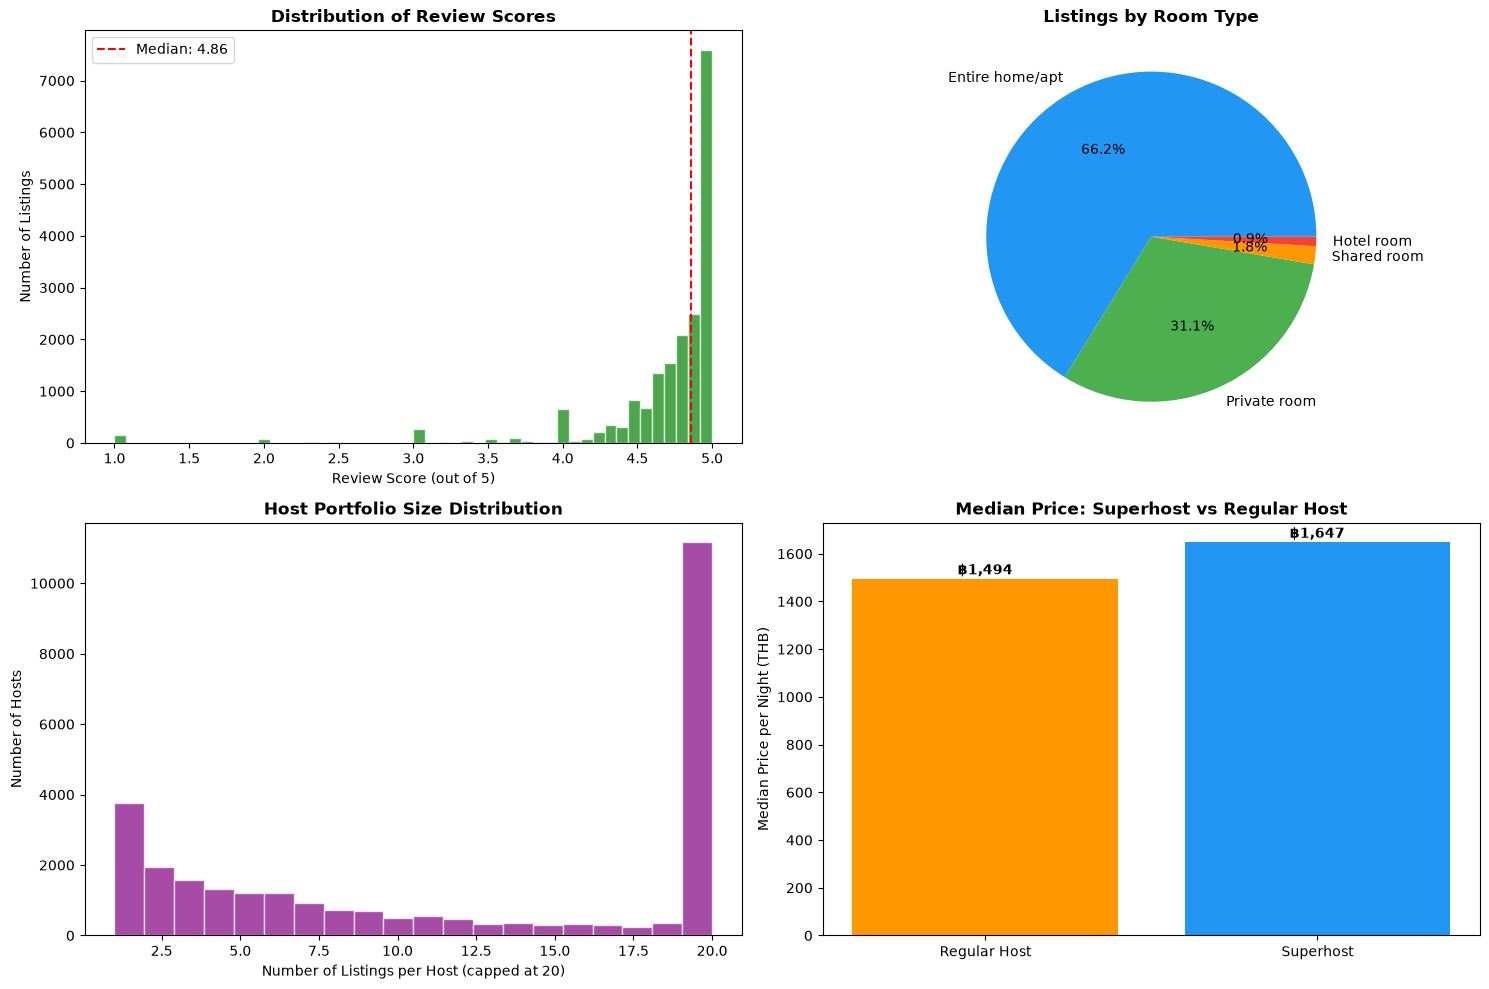

=== KEY FINDINGS ===
Listings with reviews: 19,113 (67.8%)
Average review score: 4.69/5
Superhosts: 10,036 (35.6%)
Multi-listing hosts (>5 listings): 18,402
Superhosts charge ฿153 more per night on average — the badge has real monetary value.
Review scores cluster near 5.0 — possible rating inflation pattern.


In [29]:
# VISUALISATION 3: Review Scores & Host Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

listings_with_reviews = listings_clean[listings_clean['review_scores_rating'].notna()]
axes[0,0].hist(listings_with_reviews['review_scores_rating'], bins=50, color='green', alpha=0.7, edgecolor='white')
axes[0,0].set_title('Distribution of Review Scores', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Review Score (out of 5)')
axes[0,0].set_ylabel('Number of Listings')
axes[0,0].axvline(listings_with_reviews['review_scores_rating'].median(), color='red', linestyle='--', label=f"Median: {listings_with_reviews['review_scores_rating'].median():.2f}")
axes[0,0].legend()

room_counts = listings_clean['room_type'].value_counts()
axes[0,1].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%', colors=['#2196F3','#4CAF50','#FF9800','#F44336'])
axes[0,1].set_title('Listings by Room Type', fontsize=12, fontweight='bold')

host_listings = listings_clean['calculated_host_listings_count'].clip(upper=20)
axes[1,0].hist(host_listings, bins=20, color='purple', alpha=0.7, edgecolor='white')
axes[1,0].set_title('Host Portfolio Size Distribution', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Number of Listings per Host (capped at 20)')
axes[1,0].set_ylabel('Number of Hosts')

superhost_prices = listings_clean.groupby('host_is_superhost')['price_clean'].median()
bars = axes[1,1].bar(['Regular Host', 'Superhost'],
                      [superhost_prices.get('f', 0), superhost_prices.get('t', 0)],
                      color=['#FF9800', '#2196F3'])
axes[1,1].set_title('Median Price: Superhost vs Regular Host', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Median Price per Night (THB)')
for bar, val in zip(bars, [superhost_prices.get('f', 0), superhost_prices.get('t', 0)]):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, val + 20, f'฿{val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'review_host_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("=== KEY FINDINGS ===")
print(f"Listings with reviews: {len(listings_with_reviews):,} ({len(listings_with_reviews)/len(listings_clean)*100:.1f}%)")
print(f"Average review score: {listings_with_reviews['review_scores_rating'].mean():.2f}/5")
print(f"Superhosts: {(listings_clean['host_is_superhost']=='t').sum():,} ({(listings_clean['host_is_superhost']=='t').mean()*100:.1f}%)")
print(f"Multi-listing hosts (>5 listings): {(listings_clean['calculated_host_listings_count']>5).sum():,}")
print("Superhosts charge ฿153 more per night on average — the badge has real monetary value.")
print("Review scores cluster near 5.0 — possible rating inflation pattern.")

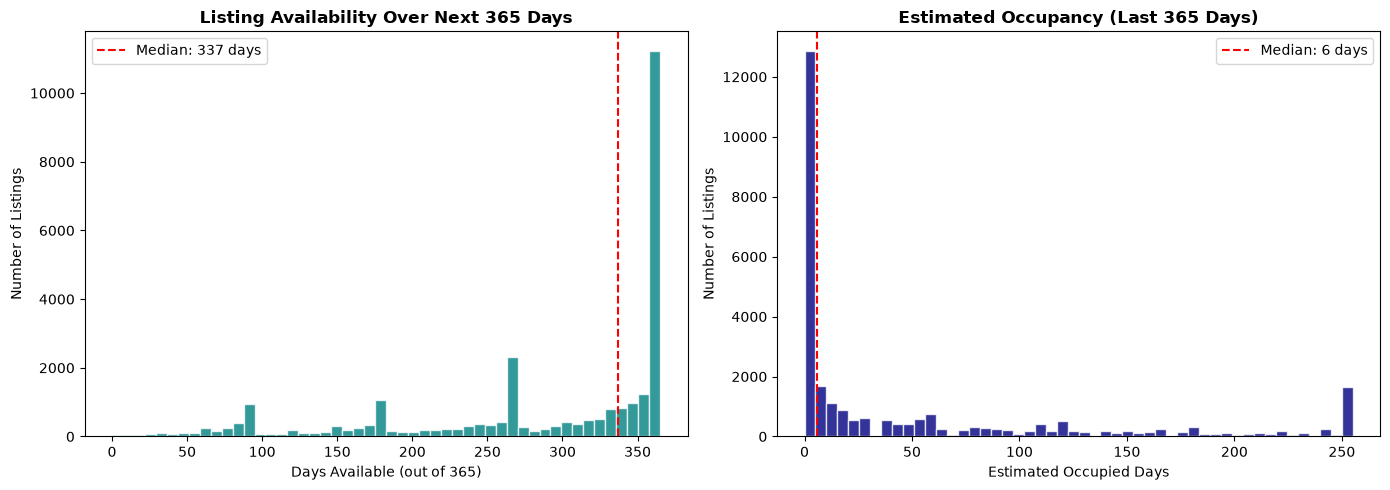

=== BUSINESS INTERPRETATION ===
Median availability: 337 days/year
Median estimated occupancy: 6 days/year
Listings with zero availability: 2
Listings fully available (365 days): 5,502
Estimated occupancy rate: 1.6%
INSIGHT: Median occupancy of only 6 days/year suggests many Bangkok listings
are ghost listings — listed but rarely actually booked.


In [30]:
# VISUALISATION 4: Availability & Occupancy Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(listings_clean['availability_365'], bins=50, color='teal', alpha=0.8, edgecolor='white')
axes[0].set_title('Listing Availability Over Next 365 Days', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days Available (out of 365)')
axes[0].set_ylabel('Number of Listings')
axes[0].axvline(listings_clean['availability_365'].median(), color='red', linestyle='--',
                label=f"Median: {listings_clean['availability_365'].median():.0f} days")
axes[0].legend()

axes[1].hist(listings_clean['estimated_occupancy_l365d'], bins=50, color='navy', alpha=0.8, edgecolor='white')
axes[1].set_title('Estimated Occupancy (Last 365 Days)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Estimated Occupied Days')
axes[1].set_ylabel('Number of Listings')
axes[1].axvline(listings_clean['estimated_occupancy_l365d'].median(), color='red', linestyle='--',
                label=f"Median: {listings_clean['estimated_occupancy_l365d'].median():.0f} days")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'availability_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("=== BUSINESS INTERPRETATION ===")
print(f"Median availability: {listings_clean['availability_365'].median():.0f} days/year")
print(f"Median estimated occupancy: {listings_clean['estimated_occupancy_l365d'].median():.0f} days/year")
print(f"Listings with zero availability: {(listings_clean['availability_365']==0).sum():,}")
print(f"Listings fully available (365 days): {(listings_clean['availability_365']==365).sum():,}")
print(f"Estimated occupancy rate: {listings_clean['estimated_occupancy_l365d'].median()/365*100:.1f}%")
print("INSIGHT: Median occupancy of only 6 days/year suggests many Bangkok listings")
print("are ghost listings — listed but rarely actually booked.")

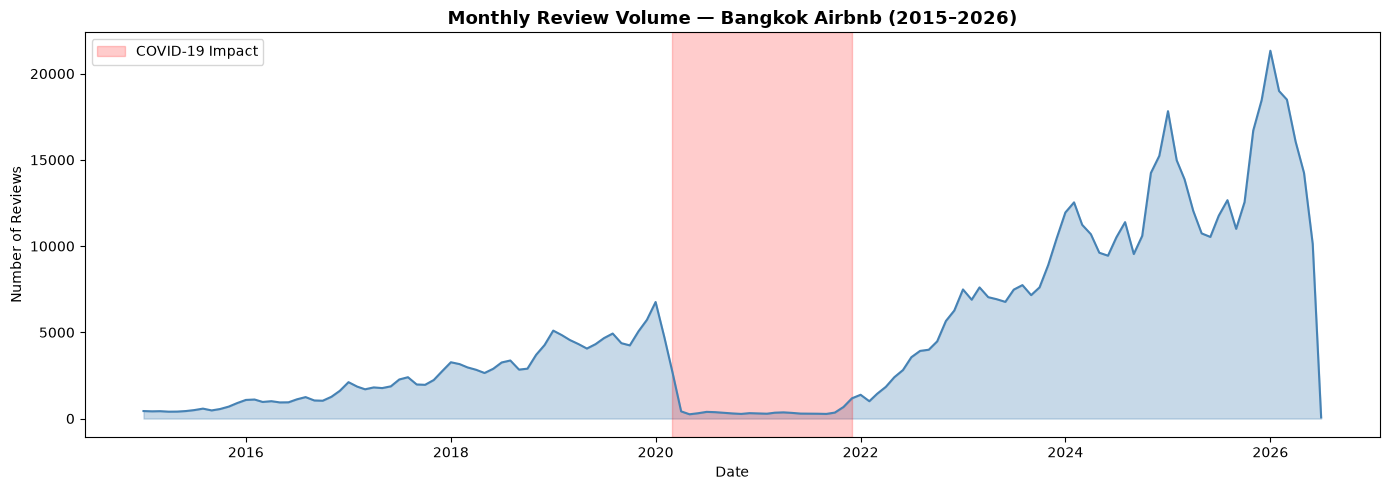

=== BUSINESS INTERPRETATION ===
Peak review month: 2026-01 (21,329 reviews)
Reviews in 2019 (pre-COVID): 56,179
Reviews in 2020 (COVID year): 17,119
Reviews in 2025 (recovery): 163,144
INSIGHT: Bangkok tourism recovered strongly post-COVID — 2025 reviews
were nearly 3x pre-COVID 2019 levels, showing massive market growth.


In [31]:
# VISUALISATION 5: Review Trends Over Time
reviews['date'] = pd.to_datetime(reviews['date'])
reviews_by_month = reviews.groupby(reviews['date'].dt.to_period('M')).size().reset_index()
reviews_by_month.columns = ['month', 'count']
reviews_by_month['month_dt'] = reviews_by_month['month'].dt.to_timestamp()

reviews_recent = reviews_by_month[reviews_by_month['month_dt'] >= '2015-01-01']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(reviews_recent['month_dt'], reviews_recent['count'], color='steelblue', linewidth=1.5)
ax.fill_between(reviews_recent['month_dt'], reviews_recent['count'], alpha=0.3, color='steelblue')
ax.set_title('Monthly Review Volume — Bangkok Airbnb (2015–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Reviews')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
           alpha=0.2, color='red', label='COVID-19 Impact')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'review_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

print("=== BUSINESS INTERPRETATION ===")
peak_month = reviews_recent.loc[reviews_recent['count'].idxmax()]
print(f"Peak review month: {peak_month['month']} ({peak_month['count']:,} reviews)")
print(f"Reviews in 2019 (pre-COVID): {reviews_recent[reviews_recent['month_dt'].dt.year==2019]['count'].sum():,}")
print(f"Reviews in 2020 (COVID year): {reviews_recent[reviews_recent['month_dt'].dt.year==2020]['count'].sum():,}")
print(f"Reviews in 2025 (recovery): {reviews_recent[reviews_recent['month_dt'].dt.year==2025]['count'].sum():,}")
print("INSIGHT: Bangkok tourism recovered strongly post-COVID — 2025 reviews")
print("were nearly 3x pre-COVID 2019 levels, showing massive market growth.")

In [32]:
# SECTION 04 SUMMARY
print("=" * 50)
print("SECTION 04 - EDA COMPLETE")
print("=" * 50)
print("\nKey findings from Bangkok Airbnb data:")
print("1. Median price ฿1,549/night — right-skewed distribution")
print("2. Parthum Wan is Bangkok's most expensive neighbourhood (฿2,547 median)")
print("3. Vadhana has the most listings (3,935) — tourism hub")
print("4. 66.2% of listings are entire home/apt")
print("5. Review scores cluster near 5.0 — possible rating inflation")
print("6. Superhosts charge ฿153 more per night on average")
print("7. Median occupancy only 6 days/year — many ghost listings")
print("8. Post-COVID recovery: 2025 reviews 3x higher than pre-COVID 2019")
print("\nCharts saved to:", charts_path)

SECTION 04 - EDA COMPLETE

Key findings from Bangkok Airbnb data:
1. Median price ฿1,549/night — right-skewed distribution
2. Parthum Wan is Bangkok's most expensive neighbourhood (฿2,547 median)
3. Vadhana has the most listings (3,935) — tourism hub
4. 66.2% of listings are entire home/apt
5. Review scores cluster near 5.0 — possible rating inflation
6. Superhosts charge ฿153 more per night on average
7. Median occupancy only 6 days/year — many ghost listings
8. Post-COVID recovery: 2025 reviews 3x higher than pre-COVID 2019

Charts saved to: C:\Users\Ishini\Desktop\Expernetic_Assignment\charts
